In [1]:
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;
import numpy as np;
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report;

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raghadalharbi/breast-cancer-gene-expression-profiles-metabric")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-gene-expression-profiles-metabric' dataset.
Path to dataset files: /kaggle/input/breast-cancer-gene-expression-profiles-metabric


In [3]:
import os

os.listdir("/kaggle/input/breast-cancer-gene-expression-profiles-metabric")

dataFrame = pd.read_csv("/kaggle/input/breast-cancer-gene-expression-profiles-metabric/METABRIC_RNA_Mutation.csv")
df=dataFrame.copy();
df.head(20)

/tmp/ipykernel_18986/2894126367.py:5: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  dataFrame = pd.read_csv("/kaggle/input/breast-cancer-gene-expression-profiles-metabric/METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
5,10,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
6,14,56.45,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
7,22,89.08,BREAST CONSERVING,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
8,28,86.41,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
9,35,84.22,MASTECTOMY,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,Her2,1.0,Negative,...,0,0,0,0,0,0,0,0,0,0


In [4]:
for cols in df.columns:
    print(cols)

patient_id
age_at_diagnosis
type_of_breast_surgery
cancer_type
cancer_type_detailed
cellularity
chemotherapy
pam50_+_claudin-low_subtype
cohort
er_status_measured_by_ihc
er_status
neoplasm_histologic_grade
her2_status_measured_by_snp6
her2_status
tumor_other_histologic_subtype
hormone_therapy
inferred_menopausal_state
integrative_cluster
primary_tumor_laterality
lymph_nodes_examined_positive
mutation_count
nottingham_prognostic_index
oncotree_code
overall_survival_months
overall_survival
pr_status
radio_therapy
3-gene_classifier_subtype
tumor_size
tumor_stage
death_from_cancer
brca1
brca2
palb2
pten
tp53
atm
cdh1
chek2
nbn
nf1
stk11
bard1
mlh1
msh2
msh6
pms2
epcam
rad51c
rad51d
rad50
rb1
rbl1
rbl2
ccna1
ccnb1
cdk1
ccne1
cdk2
cdc25a
ccnd1
cdk4
cdk6
ccnd2
cdkn2a
cdkn2b
myc
cdkn1a
cdkn1b
e2f1
e2f2
e2f3
e2f4
e2f5
e2f6
e2f7
e2f8
src
jak1
jak2
stat1
stat2
stat3
stat5a
stat5b
mdm2
tp53bp1
adam10
adam17
aph1a
aph1b
arrdc1
cir1
ctbp1
ctbp2
cul1
dll1
dll3
dll4
dtx1
dtx2
dtx3
dtx4
ep300
fbxw7
hda

In [5]:
df.size

1319472

In [6]:
df.shape

(1904, 693)

In [7]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

,0
patient_id,0
age_at_diagnosis,0
type_of_breast_surgery,22
cancer_type,0
cancer_type_detailed,15
cellularity,54
chemotherapy,0
pam50_+_claudin-low_subtype,0
cohort,0
er_status_measured_by_ihc,30


In [8]:
df["3-gene_classifier_subtype"].value_counts()

,count
3-gene_classifier_subtype,
ER+/HER2- Low Prolif,619
ER+/HER2- High Prolif,603
ER-/HER2-,290
HER2+,188


In [9]:
df = df.dropna(subset=["tumor_stage"])

In [10]:
df["3-gene_classifier_subtype"] = df["3-gene_classifier_subtype"].fillna("Unknown")

In [11]:
df = df.fillna(df.median(numeric_only=True))

In [12]:
for cols in df.columns:
    df[cols]=df[cols].fillna("Unknown")

In [13]:
df.isnull().sum()

,0
patient_id,0
age_at_diagnosis,0
type_of_breast_surgery,0
cancer_type,0
cancer_type_detailed,0
cellularity,0
chemotherapy,0
pam50_+_claudin-low_subtype,0
cohort,0
er_status_measured_by_ihc,0


In [14]:
df.shape

(1403, 693)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1403 entries, 0 to 1664
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 7.4+ MB


In [16]:
df.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,...,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000
mean,3123.385602,60.587641,0.217391,2.174626,2.456878,0.607983,1.895225,5.468995,4.040902,127.677025,...,-0.014788,0.010055,-0.014861,-0.036682,-0.018827,-0.010448,-0.026310,0.012942,-0.011814,-0.006231
std,2093.858453,12.985638,0.412618,0.956328,0.641048,0.488375,3.933614,3.728232,1.134618,77.994640,...,0.982655,0.984800,1.024585,0.980934,1.008114,0.990755,1.001541,0.996643,0.976171,1.005012
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.020000,0.100000,...,-2.120800,-3.024100,-1.935100,-4.982700,-2.936400,-3.833300,-3.609300,-1.166900,-2.112600,-1.051600
25%,531.500000,50.995000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,61.850000,...,-0.626400,-0.591500,-0.700100,-0.628100,-0.654950,-0.661100,-0.728000,-0.499000,-0.484600,-0.731900
50%,3470.000000,61.120000,0.000000,2.000000,3.000000,1.000000,0.000000,5.000000,4.042000,117.566667,...,-0.258800,-0.030300,-0.158400,-0.069800,-0.060500,-0.020400,-0.058200,-0.281200,-0.133400,-0.440700
75%,5060.500000,69.875000,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.042000,188.883333,...,0.315650,0.519150,0.492600,0.508550,0.549250,0.618300,0.576150,0.074100,0.262450,0.372150
max,6346.000000,96.290000,1.000000,5.000000,3.000000,1.000000,41.000000,46.000000,6.360000,351.000000,...,5.554400,9.493500,6.329000,4.571300,12.742300,3.938800,3.833400,8.619900,12.643900,3.260800


In [17]:
df["tumor_stage"].value_counts()

,count
tumor_stage,
2.0,800
1.0,475
3.0,115
4.0,9
0.0,4


In [18]:
df=df.drop("patient_id",axis=1)
for cols in df.columns:
    print(df[cols].value_counts())
    print("*"*50)

Streaming output truncated to the last 5000 lines.
S1434N                                               1
S1330L F800Lfs*22                                    1
K1446Hfs*14 A1445Kfs*18 E1184Kfs*6 A1445Vfs*20       1
Q280*                                                1
L1291Efs*4 D630Rfs*18 I1439F                         1
L1410Hfs*8                                           1
G330*                                                1
G172E                                                1
L765Ffs*7                                            1
S699Nfs*22                                           1
P938T                                                1
P1053Afs*4                                           1
V719Efs*4                                            1
E862* Y1237C                                         1
R481K                                                1
M811V                                                1
G343Wfs*42 S297*                                     1
A726Kfs*14    

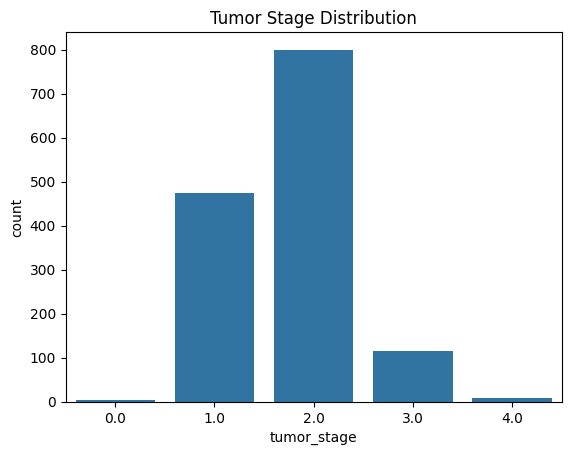

In [19]:
sns.countplot(x="tumor_stage",data = df);
plt.title("Tumor Stage Distribution")
plt.show()

In [20]:
df.dtypes

,0
age_at_diagnosis,float64
type_of_breast_surgery,object
cancer_type,object
cancer_type_detailed,object
cellularity,object
chemotherapy,int64
pam50_+_claudin-low_subtype,object
cohort,float64
er_status_measured_by_ihc,object
er_status,object


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
nums_cols=df.select_dtypes(include=["float","int"]).columns
print(nums_cols)
obj_cols=df.select_dtypes(include=["object"]).columns
print(obj_cols)

Index(['age_at_diagnosis', 'chemotherapy', 'cohort',
       'neoplasm_histologic_grade', 'hormone_therapy',
       'lymph_nodes_examined_positive', 'mutation_count',
       'nottingham_prognostic_index', 'overall_survival_months',
       'overall_survival',
       ...
       'srd5a1', 'srd5a2', 'srd5a3', 'st7', 'star', 'tnk2', 'tulp4', 'ugt2b15',
       'ugt2b17', 'ugt2b7'],
      dtype='object', length=502)
Index(['type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed',
       'cellularity', 'pam50_+_claudin-low_subtype',
       'er_status_measured_by_ihc', 'er_status',
       'her2_status_measured_by_snp6', 'her2_status',
       'tumor_other_histologic_subtype',
       ...
       'mtap_mut', 'ppp2cb_mut', 'smarcd1_mut', 'nras_mut', 'ndfip1_mut',
       'hras_mut', 'prps2_mut', 'smarcb1_mut', 'stmn2_mut', 'siah1_mut'],
      dtype='object', length=190)


In [23]:
df[nums_cols].describe()

,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,overall_survival,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,...,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000
mean,60.587641,0.217391,2.174626,2.456878,0.607983,1.895225,5.468995,4.040902,127.677025,0.435495,...,-0.014788,0.010055,-0.014861,-0.036682,-0.018827,-0.010448,-0.026310,0.012942,-0.011814,-0.006231
std,12.985638,0.412618,0.956328,0.641048,0.488375,3.933614,3.728232,1.134618,77.994640,0.495998,...,0.982655,0.984800,1.024585,0.980934,1.008114,0.990755,1.001541,0.996643,0.976171,1.005012
min,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.020000,0.100000,0.000000,...,-2.120800,-3.024100,-1.935100,-4.982700,-2.936400,-3.833300,-3.609300,-1.166900,-2.112600,-1.051600
25%,50.995000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,61.850000,0.000000,...,-0.626400,-0.591500,-0.700100,-0.628100,-0.654950,-0.661100,-0.728000,-0.499000,-0.484600,-0.731900
50%,61.120000,0.000000,2.000000,3.000000,1.000000,0.000000,5.000000,4.042000,117.566667,0.000000,...,-0.258800,-0.030300,-0.158400,-0.069800,-0.060500,-0.020400,-0.058200,-0.281200,-0.133400,-0.440700
75%,69.875000,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.042000,188.883333,1.000000,...,0.315650,0.519150,0.492600,0.508550,0.549250,0.618300,0.576150,0.074100,0.262450,0.372150
max,96.290000,1.000000,5.000000,3.000000,1.000000,41.000000,46.000000,6.360000,351.000000,1.000000,...,5.554400,9.493500,6.329000,4.571300,12.742300,3.938800,3.833400,8.619900,12.643900,3.260800


<Axes: xlabel='tumor_stage', ylabel='age_at_diagnosis'>

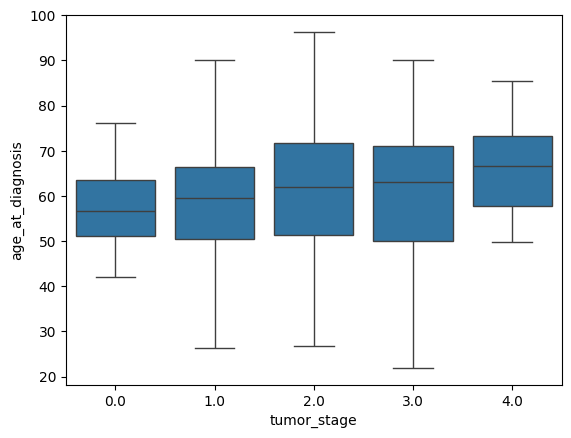

In [24]:
sns.boxplot(x="tumor_stage",y="age_at_diagnosis",data=df)

<Axes: xlabel='type_of_breast_surgery', ylabel='tumor_stage'>

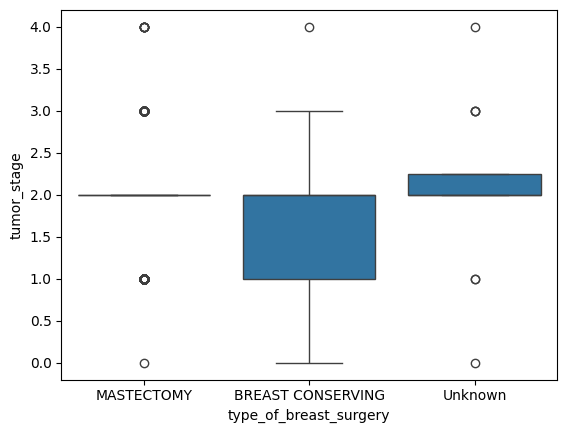

In [25]:
sns.boxplot(x="type_of_breast_surgery",y="tumor_stage",data=df)

<Axes: xlabel='tumor_stage', ylabel='lymph_nodes_examined_positive'>

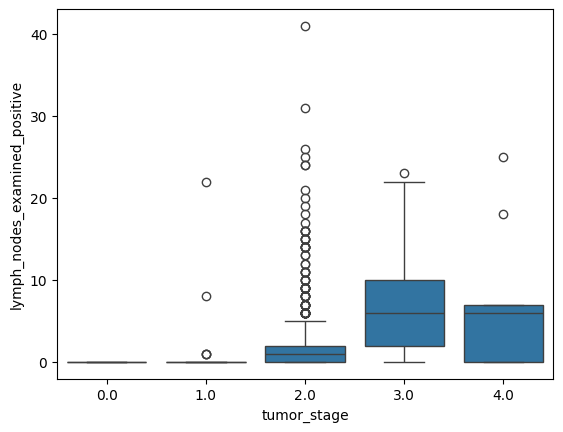

In [26]:
sns.boxplot(x='tumor_stage', y='lymph_nodes_examined_positive', data=df)

<Axes: xlabel='cellularity', ylabel='tumor_stage'>

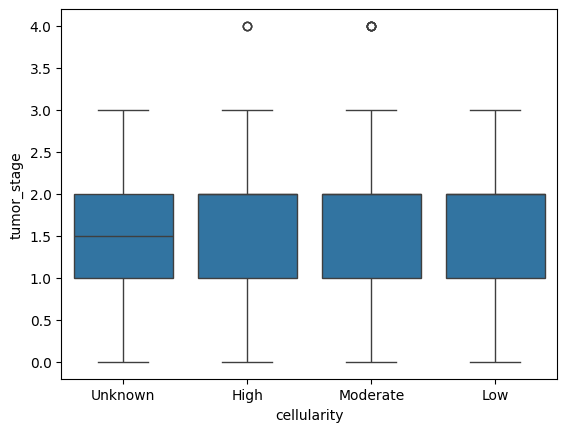

In [27]:
sns.boxplot(y="tumor_stage",x="cellularity",data=df)

<Axes: xlabel='chemotherapy', ylabel='tumor_stage'>

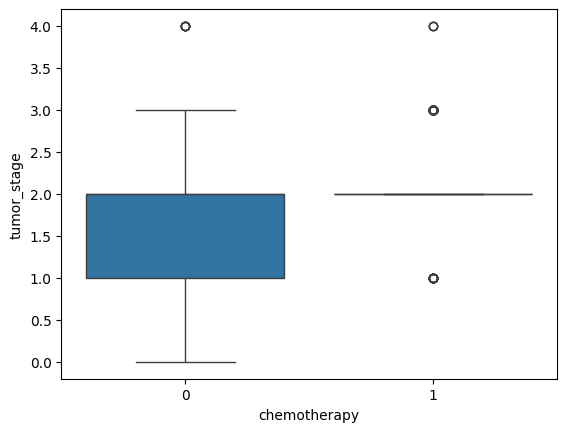

In [28]:
sns.boxplot(y="tumor_stage",x="chemotherapy",data=df)

<Axes: xlabel='tumor_stage', ylabel='count'>

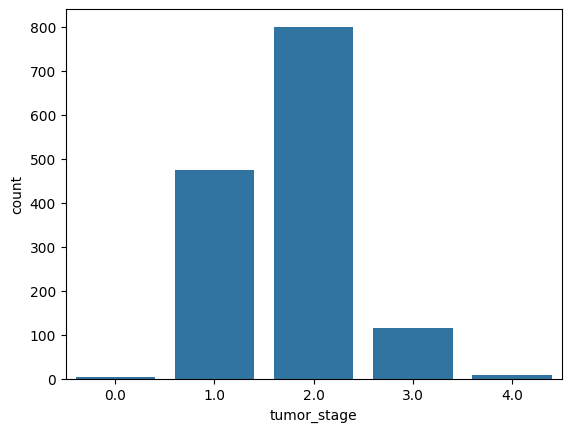

In [29]:
sns.countplot(x="tumor_stage",data=df)

In [30]:
df["tumor_stage"].unique()

array([2., 1., 4., 3., 0.])

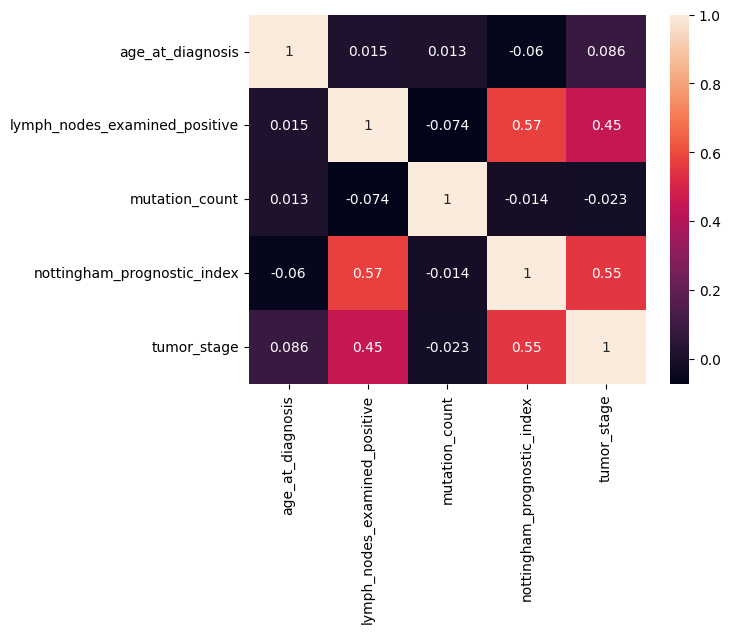

In [31]:
clinical_cols = [
'age_at_diagnosis',
'lymph_nodes_examined_positive',
'mutation_count',
'nottingham_prognostic_index',
'tumor_stage'
]

sns.heatmap(df[clinical_cols].corr(), annot=True)
plt.show()

In [32]:
mut_cols = [c for c in df.columns if c.endswith('_mut')]

for col in mut_cols:
    df[col] = df[col].apply(lambda x: 0 if str(x) in ['0','0.0'] else 1)

In [33]:
# for cols in obj_cols:
#     print(cols,"---->",df[cols].unique())
#     print("*"*50)

In [34]:
df=df.drop("cancer_type",axis=1)

In [35]:
df.head()

,age_at_diagnosis,type_of_breast_surgery,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,75.65,MASTECTOMY,Breast Invasive Ductal Carcinoma,Unknown,0,claudin-low,1.0,Positve,Positive,3.0,...,0,0,0,0,0,0,0,0,0,0
1,43.19,BREAST CONSERVING,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,...,0,0,0,0,0,0,0,0,0,0
2,48.87,MASTECTOMY,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,...,0,0,0,0,0,0,0,0,0,0
3,47.68,MASTECTOMY,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,...,0,0,0,0,0,0,0,0,0,0
4,76.97,MASTECTOMY,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,3.0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
binary_map={"Positive":1,"Negative":0};
df["er_status"]=df["er_status"].map(binary_map);
df["her2_status"]=df["her2_status"].map(binary_map);
df["pr_status"]=df["pr_status"].map(binary_map);

In [37]:
df["er_status_measured_by_ihc"]=df["er_status_measured_by_ihc"].map({"Positve":1,"Negative":0,"Unknown":np.nan});
df["inferred_menopausal_state"]=df["inferred_menopausal_state"].map({"Post":1,"Pre":0});

In [38]:
df["er_status_measured_by_ihc"] = df["er_status_measured_by_ihc"].fillna(
    df["er_status_measured_by_ihc"].mode()[0]
)

In [39]:
df["er_status_measured_by_ihc"].unique()

array([1., 0.])

In [40]:
cat_cols = [
'type_of_breast_surgery',
'cellularity',
'pam50_+_claudin-low_subtype',
'her2_status_measured_by_snp6',
'tumor_other_histologic_subtype',
'integrative_cluster',
'primary_tumor_laterality',
'oncotree_code',
'3-gene_classifier_subtype',
'death_from_cancer'
]
df[cat_cols]=df[cat_cols].replace("Unknown",np.nan);
for cols in cat_cols:
  df[cols]=df[cols].fillna(df[cols].mode()[0]);
df = pd.get_dummies(df, columns=cat_cols, drop_first=True);

In [41]:
obj_cols=df.select_dtypes(include=["object"])
for cols in obj_cols:
    print(cols,"---->",df[cols].unique())
    print("*"*50)

cancer_type_detailed ----> ['Breast Invasive Ductal Carcinoma'
 'Breast Mixed Ductal and Lobular Carcinoma'
 'Breast Invasive Lobular Carcinoma'
 'Breast Invasive Mixed Mucinous Carcinoma' 'Breast' 'Unknown'
 'Metaplastic Breast Cancer']
**************************************************


In [42]:
df['cancer_type_detailed'] = df['cancer_type_detailed'].replace('Unknown', np.nan);
df['cancer_type_detailed'] = df['cancer_type_detailed'].fillna(df['cancer_type_detailed'].mode()[0]);

In [43]:
df = pd.get_dummies(df, columns=['cancer_type_detailed'], drop_first=True)

In [44]:
df["tumor_stage"]=df["tumor_stage"].replace({0:1,4:3})

In [45]:
obj_cols=df.select_dtypes(include=["object"])
for cols in obj_cols:
    print(cols,"---->",df[cols].unique())
    print("*"*50)

In [46]:
bool_cols=df.select_dtypes(include=["bool"]);
for cols in bool_cols:
  df[cols]=df[cols].astype(int);

In [47]:
df.corr()["tumor_stage"].sort_values(ascending=False).head(11)

,tumor_stage
tumor_stage,1.000000
nottingham_prognostic_index,0.553085
tumor_size,0.521395
lymph_nodes_examined_positive,0.447709
chemotherapy,0.346222
type_of_breast_surgery_MASTECTOMY,0.254766
hormone_therapy,0.221689
gsk3b,0.177944
neoplasm_histologic_grade,0.171388
aurka,0.164835


In [93]:
features = [
    "nottingham_prognostic_index",
    "tumor_size",
    "lymph_nodes_examined_positive",
    "chemotherapy",
    # "type_of_breast_surgery",
    "hormone_therapy",
    "neoplasm_histologic_grade",
    "radio_therapy",
    "age_at_diagnosis",
    "er_status",
    "her2_status",
    # "tumor_grade",
    "inferred_menopausal_state",
    # "type_of_breast_surgery_MASTECTOMY",
    "aurka"
]

In [80]:
for cols in modified_dataset.columns:
  print(cols,"---->",modified_dataset[cols].unique())
  print("*"*50)

nottingham_prognostic_index ----> [6.044   4.02    4.03    4.05    6.08    4.062   4.058   5.032   3.056
 3.044   2.042   5.038   6.072   4.066   3.046   4.072   3.058   4.046
 4.034   3.036   4.032   3.024   3.048   3.026   5.028   4.11    5.06
 4.078   3.068   5.08    4.14    4.036   4.09    2.054   6.3     5.034
 3.06    4.12    5.052   3.04    4.1     2.018   3.07    4.026   3.028
 6.048   2.034   3.16    5.044   5.07    4.06    4.054   3.032   6.052
 5.076   4.038   6.1     4.024   4.028   5.054   6.104   5.048   3.052
 4.04    6.088   4.048   2.04    4.088   4.042   6.068   3.05    6.096
 2.026   6.038   5.042   6.056   6.036   4.076   5.05    2.02    4.056
 3.006   3.08    5.04    6.04    3.038   3.034   1.07    1.06    6.07
 2.092   4.044   2.022   1.028   4.022   6.      1.024   4.052   1.054
 5.062   5.106   3.042   1.      5.056   2.05    5.11    3.018   5.046
 6.058   6.02    2.038   2.094   3.066   1.036   5.064   6.064   5.068
 6.032   2.044   5.16    3.1     5.134   5.1 

In [49]:
x=pd.DataFrame()
for cols in features:
  x[cols]=df[cols];

In [89]:
x.shape

(1403, 12)

In [87]:
x.shape

(1403, 12)

In [52]:
y=df["tumor_stage"]

In [53]:
from sklearn.model_selection import train_test_split;
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42);

In [54]:
from sklearn.preprocessing import StandardScaler;
scaler=StandardScaler();
x_train_scaled=scaler.fit_transform(x_train);
x_test_scaled=scaler.transform(x_test);

In [55]:
from sklearn.linear_model import LogisticRegression;
lr=LogisticRegression(max_iter=1000);
lr.fit(x_train_scaled,y_train);
y_pred=lr.predict(x_test_scaled);
y_lr=y_pred

In [56]:
print(accuracy_score(y_test,y_pred),"\n\n")
print(confusion_matrix(y_test,y_pred),"\n\n")
print(classification_report(y_test,y_pred))

0.8207343412526998 


[[141  19   0]
 [ 32 225   5]
 [  1  26  14]] 


              precision    recall  f1-score   support

         1.0       0.81      0.88      0.84       160
         2.0       0.83      0.86      0.85       262
         3.0       0.74      0.34      0.47        41

    accuracy                           0.82       463
   macro avg       0.79      0.69      0.72       463
weighted avg       0.82      0.82      0.81       463



In [57]:
from sklearn.tree import DecisionTreeClassifier;
dt=DecisionTreeClassifier();
dt.fit(x_train,y_train);

In [58]:
y_pred=dt.predict(x_test);
y_dt=y_pred
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7883369330453563
[[140  19   1]
 [ 19 209  34]
 [  3  22  16]]
              precision    recall  f1-score   support

         1.0       0.86      0.88      0.87       160
         2.0       0.84      0.80      0.82       262
         3.0       0.31      0.39      0.35        41

    accuracy                           0.79       463
   macro avg       0.67      0.69      0.68       463
weighted avg       0.80      0.79      0.79       463



In [59]:
from sklearn.ensemble import RandomForestClassifier;
rf=RandomForestClassifier();
rf.fit(x_train,y_train);

In [60]:
y_pred=rf.predict(x_test);
y_rf=y_pred
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8704103671706264
[[144  16   0]
 [  8 244  10]
 [  1  25  15]]
              precision    recall  f1-score   support

         1.0       0.94      0.90      0.92       160
         2.0       0.86      0.93      0.89       262
         3.0       0.60      0.37      0.45        41

    accuracy                           0.87       463
   macro avg       0.80      0.73      0.76       463
weighted avg       0.86      0.87      0.86       463



In [61]:
from sklearn.svm import SVC;
svm=SVC();
svm.fit(x_train_scaled,y_train);

In [62]:
y_pred=svm.predict(x_test_scaled);
y_svm=y_pred
print(accuracy_score(y_test,y_pred));
print(confusion_matrix(y_test,y_pred));
print(classification_report(y_test,y_pred));

0.8142548596112311
[[143  17   0]
 [ 33 225   4]
 [  1  31   9]]
              precision    recall  f1-score   support

         1.0       0.81      0.89      0.85       160
         2.0       0.82      0.86      0.84       262
         3.0       0.69      0.22      0.33        41

    accuracy                           0.81       463
   macro avg       0.77      0.66      0.67       463
weighted avg       0.81      0.81      0.80       463



In [63]:
from sklearn.ensemble import GradientBoostingClassifier;
gb=GradientBoostingClassifier();
gb.fit(x_train,y_train);

In [64]:
y_pred=gb.predict(x_test);
y_gb=y_pred
print(accuracy_score(y_test,y_pred));
print(confusion_matrix(y_test,y_pred));
print(classification_report(y_test,y_pred));

0.8552915766738661
[[138  22   0]
 [  8 238  16]
 [  1  20  20]]
              precision    recall  f1-score   support

         1.0       0.94      0.86      0.90       160
         2.0       0.85      0.91      0.88       262
         3.0       0.56      0.49      0.52        41

    accuracy                           0.86       463
   macro avg       0.78      0.75      0.77       463
weighted avg       0.85      0.86      0.85       463



In [65]:
from sklearn.neighbors import KNeighborsClassifier;
knn=KNeighborsClassifier();
knn.fit(x_train,y_train);

In [66]:
y_pred=knn.predict(x_test);
y_knn=y_pred
print(accuracy_score(y_test,y_pred));
print(confusion_matrix(y_test,y_pred));
print(classification_report(y_test,y_pred));

0.7667386609071274
[[131  29   0]
 [ 41 209  12]
 [  1  25  15]]
              precision    recall  f1-score   support

         1.0       0.76      0.82      0.79       160
         2.0       0.79      0.80      0.80       262
         3.0       0.56      0.37      0.44        41

    accuracy                           0.77       463
   macro avg       0.70      0.66      0.67       463
weighted avg       0.76      0.77      0.76       463



In [67]:
from xgboost import XGBClassifier;
xgb=XGBClassifier();
xgb.fit(x_train,y_train-1);

In [68]:
y_pred=xgb.predict(x_test);
y_xgb=y_pred
print(accuracy_score(y_test-1,y_pred));
print(confusion_matrix(y_test-1,y_pred));
print(classification_report(y_test-1,y_pred));

0.8682505399568035
[[146  14   0]
 [ 12 237  13]
 [  1  21  19]]
              precision    recall  f1-score   support

         0.0       0.92      0.91      0.92       160
         1.0       0.87      0.90      0.89       262
         2.0       0.59      0.46      0.52        41

    accuracy                           0.87       463
   macro avg       0.79      0.76      0.77       463
weighted avg       0.86      0.87      0.86       463



In [69]:
from sklearn.linear_model import Ridge;
ridge=Ridge();
ridge.fit(x_train,y_train);

In [70]:
y_pred=np.round(ridge.predict(x_test))
y_ridge=y_pred
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred));
print(classification_report(y_test,y_pred))

0.7926565874730022
[[  0   0   0   0   0]
 [  1 125  34   0   0]
 [  0  28 228   6   0]
 [  0   1  25  14   1]
 [  0   0   0   0   0]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       0.81      0.78      0.80       160
         2.0       0.79      0.87      0.83       262
         3.0       0.70      0.34      0.46        41
         4.0       0.00      0.00      0.00         0

    accuracy                           0.79       463
   macro avg       0.46      0.40      0.42       463
weighted avg       0.79      0.79      0.79       463



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [71]:
from sklearn.linear_model import Lasso;
lasso=Lasso();
lasso.fit(x_train,y_train);

In [72]:
y_pred=np.round(lasso.predict(x_test))
y_lasso=y_pred
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred));
print(classification_report(y_test,y_pred))

0.5982721382289417
[[ 17 143   0]
 [  6 255   1]
 [  1  35   5]]
              precision    recall  f1-score   support

         1.0       0.71      0.11      0.18       160
         2.0       0.59      0.97      0.73       262
         3.0       0.83      0.12      0.21        41

    accuracy                           0.60       463
   macro avg       0.71      0.40      0.38       463
weighted avg       0.65      0.60      0.50       463



In [73]:
y_pred_res={
    "lr":y_lr,
    "dt":y_dt,
    "rf":y_rf,
    "svm":y_svm,
    "gb":y_gb,
    "knn":y_knn,
    "xgb":y_xgb,
    "ridge":y_ridge,
    "lasso":y_lasso
}
# y_accuracy=[];
for name, pred in y_pred_res.items():
    acc = accuracy_score(y_test, pred)
    print(name, acc)

lr 0.8207343412526998
dt 0.7883369330453563
rf 0.8704103671706264
svm 0.8142548596112311
gb 0.8552915766738661
knn 0.7667386609071274
xgb 0.058315334773218146
ridge 0.7926565874730022
lasso 0.5982721382289417


In [74]:
import pickle as pkl
with open("model.pkl","wb") as f:
  pkl.dump(rf,f)

In [99]:
with open("model.pkl", "rb") as f:
    model = pkl.load(f)
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

0.8704103671706264

In [100]:
print(y_pred)

[1. 2. 2. 2. 1. 3. 3. 2. 2. 2. 2. 2. 1. 1. 2. 2. 1. 2. 3. 1. 2. 1. 2. 1.
 1. 2. 1. 2. 2. 1. 2. 2. 2. 1. 2. 3. 1. 2. 1. 2. 2. 2. 1. 2. 2. 1. 2. 2.
 2. 2. 2. 1. 1. 2. 2. 3. 1. 1. 1. 2. 2. 1. 2. 3. 2. 2. 1. 2. 1. 3. 2. 2.
 2. 2. 2. 3. 2. 2. 1. 2. 1. 3. 2. 2. 2. 2. 1. 1. 2. 2. 1. 2. 2. 1. 1. 1.
 1. 2. 1. 2. 2. 1. 1. 2. 2. 1. 1. 2. 2. 2. 1. 2. 1. 2. 2. 2. 1. 2. 1. 1.
 1. 1. 1. 2. 2. 1. 2. 2. 2. 2. 2. 2. 1. 1. 2. 2. 2. 1. 1. 1. 2. 2. 2. 2.
 2. 1. 2. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2. 1. 1. 2. 2. 1. 1. 2. 2. 2.
 1. 2. 2. 2. 1. 2. 2. 1. 2. 2. 1. 2. 2. 2. 2. 1. 2. 1. 2. 2. 1. 1. 2. 1.
 2. 2. 1. 2. 2. 2. 2. 3. 3. 1. 2. 1. 2. 2. 2. 3. 2. 2. 2. 1. 2. 2. 1. 2.
 2. 2. 2. 2. 2. 1. 2. 2. 1. 2. 1. 2. 1. 3. 2. 3. 2. 1. 1. 2. 2. 1. 2. 2.
 1. 2. 2. 2. 2. 2. 2. 1. 1. 3. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2.
 2. 1. 2. 2. 1. 2. 2. 3. 1. 2. 2. 1. 2. 2. 2. 2. 1. 1. 2. 2. 2. 2. 2. 2.
 1. 2. 1. 3. 3. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1. 1. 2. 2. 2. 1. 1.
 2. 2. 2. 2. 1. 1. 2. 1. 1. 1. 3. 3. 2. 1. 2. 3. 1.

In [76]:
pkl.dump(scaler, open("scaler.pkl", "wb"))

In [92]:
modified_dataset.head(10)

,nottingham_prognostic_index,tumor_size,lymph_nodes_examined_positive,chemotherapy,hormone_therapy,neoplasm_histologic_grade,radio_therapy,age_at_diagnosis,er_status,her2_status,inferred_menopausal_state,aurka,tumor_stage
0,6.044,22.0,10.0,0,1,3.0,1,75.65,Positive,Negative,Post,-1.5733,2.0
1,4.020,10.0,0.0,0,1,3.0,1,43.19,Positive,Negative,Pre,-0.3052,1.0
2,4.030,15.0,1.0,1,1,2.0,0,48.87,Positive,Negative,Pre,-0.2248,2.0
3,4.050,25.0,3.0,1,1,2.0,1,47.68,Positive,Negative,Pre,2.0447,2.0
4,6.080,40.0,8.0,1,1,3.0,1,76.97,Positive,Negative,Post,0.5882,2.0
5,4.062,31.0,0.0,0,1,3.0,1,78.77,Positive,Negative,Post,0.9681,4.0
6,4.020,10.0,1.0,1,1,2.0,1,56.45,Positive,Negative,Post,-1.0166,2.0
7,4.058,29.0,1.0,0,1,2.0,1,89.08,Positive,Negative,Post,-0.3788,2.0
8,5.032,16.0,1.0,0,1,3.0,1,86.41,Positive,Negative,Post,0.4572,2.0
9,3.056,28.0,0.0,0,0,2.0,0,84.22,Positive,Negative,Post,-0.2941,2.0
